# Algoritma Berbasis Pohon dan Metode Ensemble

Catatan ini menguraikan konsep dasar dari Pohon Keputusan (*Decision Trees*) dan bagaimana algoritma ini dikembangkan menjadi model yang jauh lebih tangguh melalui Metode *Ensemble*. Metode *Ensemble* bekerja dengan prinsip menggabungkan banyak model sederhana untuk menghasilkan satu model prediksi yang sangat akurat dan stabil.

Fokus utama pada modul ini adalah memahami arsitektur dasar Pohon Keputusan, kerentanan algoritma ini terhadap *overfitting*, serta penerapan dua algoritma *Ensemble* paling populer di industri sains data: *Random Forests* dan *Gradient Boosted Decision Trees*.

#### **Tujuan Pembelajaran**
* Memahami mekanisme kerja aturan *if/else* pada *Decision Trees*.
* Mengatasi masalah *overfitting* pada pohon tunggal menggunakan teknik pemangkasan awal (*Pre-pruning* / membatasi kedalaman maksimum pohon).
* Memahami konsep *Feature Importance* untuk interpretasi kontribusi fitur.
* Menerapkan *Random Forests* yang menggunakan prinsip pengacakan data (Bootstrap) dan fitur untuk meredam variansi.
* Menerapkan *Gradient Boosting* yang membangun pohon secara sekuensial untuk memperbaiki kesalahan (*error*) model secara bertahap.

In [33]:
# Memuat pustaka komputasi numerik dan visualisasi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Memuat pemisah data dan dataset Kanker Payudara
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

# Memuat keluarga algoritma berbasis pohon
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Konfigurasi visualisasi
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

print("Pustaka untuk Algoritma Berbasis Pohon berhasil dimuat.")

Pustaka untuk Algoritma Berbasis Pohon berhasil dimuat.


## 1. Pohon Keputusan (*Decision Trees*)

Pohon keputusan bekerja dengan mempelajari hierarki pertanyaan *if/else* yang berujung pada sebuah keputusan (klasifikasi). Meskipun algoritma ini sangat mudah diinterpretasikan dan tidak memerlukan penskalaan fitur (*Feature Scaling*), pohon keputusan tunggal memiliki kelemahan yang sangat fatal: **Sangat rentan terhadap Overfitting**.

Jika dibiarkan tumbuh tanpa batas, pohon akan terus membuat simpul cabang hingga seluruh daunnya murni (*pure leaves*), yang berarti model menghafal seluruh data latih secara presisi namun gagal melakukan generalisasi pada data uji. Solusi utamanya adalah **Pre-pruning** (pemangkasan awal), yaitu menghentikan pertumbuhan pohon dengan membatasi kedalaman maksimalnya menggunakan parameter `max_depth`.

In [34]:
# Memuat Dataset Kanker Payudara
cancer = load_breast_cancer()
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    cancer.data, cancer.target, stratify=cancer.target, random_state=42
)

# 1. Decision Tree tanpa batasan (Akan mengalami Overfitting)
tree_unpruned = DecisionTreeClassifier(random_state=0)
tree_unpruned.fit(X_train_t, y_train_t)

print("=== Pohon Keputusan Tanpa Batasan (Unpruned) ===")
print(f"Akurasi Latih : {tree_unpruned.score(X_train_t, y_train_t):.4f} (Menghafal Sempurna)")
print(f"Akurasi Uji   : {tree_unpruned.score(X_test_t, y_test_t):.4f}")

# 2. Decision Tree dengan Pre-pruning (Membatasi kedalaman maksimal menjadi 4)
tree_pruned = DecisionTreeClassifier(max_depth=4, random_state=0)
tree_pruned.fit(X_train_t, y_train_t)

print("\n=== Pohon Keputusan dengan Pre-pruning (max_depth=4) ===")
print(f"Akurasi Latih : {tree_pruned.score(X_train_t, y_train_t):.4f}")
print(f"Akurasi Uji   : {tree_pruned.score(X_test_t, y_test_t):.4f}")
print("Analisis: Membatasi kedalaman pohon menurunkan akurasi latih, namun mendongkrak kemampuan generalisasi pada data uji.")

=== Pohon Keputusan Tanpa Batasan (Unpruned) ===
Akurasi Latih : 1.0000 (Menghafal Sempurna)
Akurasi Uji   : 0.9371

=== Pohon Keputusan dengan Pre-pruning (max_depth=4) ===
Akurasi Latih : 0.9883
Akurasi Uji   : 0.9510
Analisis: Membatasi kedalaman pohon menurunkan akurasi latih, namun mendongkrak kemampuan generalisasi pada data uji.


## 2. Interpretasi Model: Tingkat Kepentingan Fitur

Alih-alih menelusuri seluruh cabang pohon yang rumit, kita dapat menginspeksi properti `feature_importances_`. Properti ini memberikan skor antara 0 dan 1 untuk setiap fitur.

* Nilai `0` berarti fitur tersebut tidak digunakan sama sekali dalam pengambilan keputusan.
* Nilai `1` berarti fitur tersebut memprediksi target secara sempurna. Jumlah keseluruhan skor kepentingan fitur akan selalu bernilai 1.

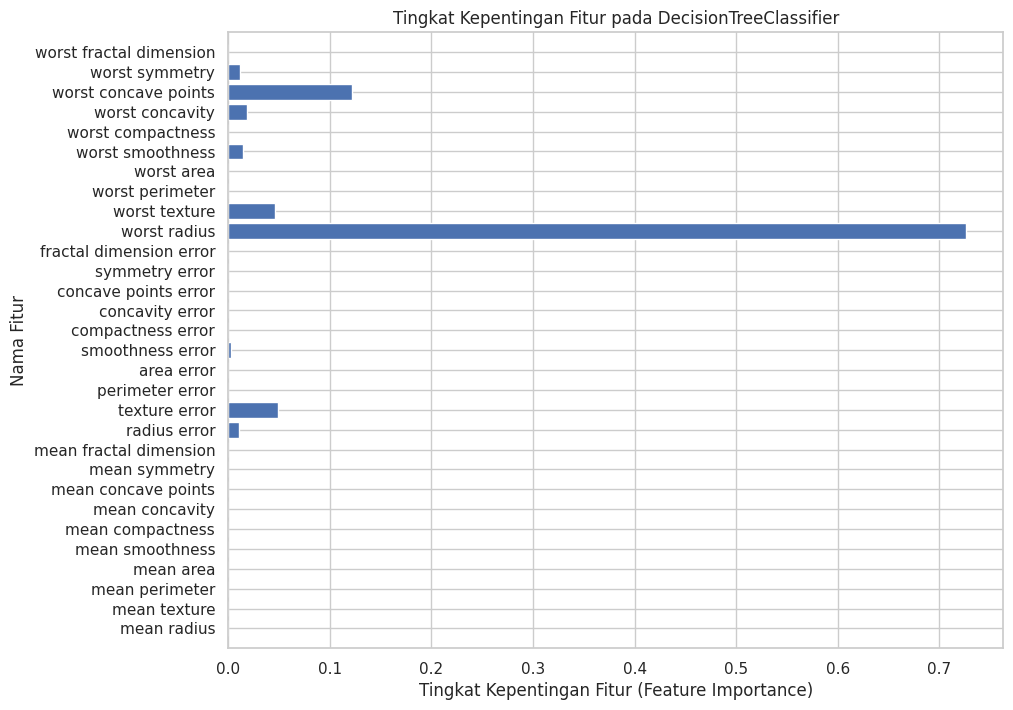

In [35]:
def plot_feature_importances(model, dataset):
    n_features = dataset.data.shape[1]
    plt.figure(figsize=(10, 8))
    plt.barh(np.arange(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), dataset.feature_names)
    plt.xlabel("Tingkat Kepentingan Fitur (Feature Importance)")
    plt.ylabel("Nama Fitur")
    plt.title(f"Tingkat Kepentingan Fitur pada {model.__class__.__name__}")
    plt.ylim(-1, n_features)
    plt.show()

# Memvisualisasikan Feature Importance dari model pohon yang telah di-pruning
plot_feature_importances(tree_pruned, cancer)

## 3. Metode Ensemble: Random Forests

Untuk mengatasi kelemahan pohon keputusan yang mudah *overfit*, kita menggunakan **Random Forests**. Konsep dasarnya adalah: kumpulan banyak pohon akan menghasilkan keputusan yang lebih baik daripada satu pohon.

Algoritma ini membangun banyak Pohon Keputusan secara independen dengan menginjeksikan dua unsur keacakan:
1. **Bootstrap Sampling:** Setiap pohon dilatih menggunakan sampel data yang diambil secara acak (dengan pengembalian) dari data latih asli.
2. **Feature Randomness:** Pada setiap pemisahan simpul (*node split*), algoritma hanya mempertimbangkan sebagian subset fitur yang dipilih secara acak.

Hasil prediksi akhirnya ditentukan melalui *voting* mayoritas dari seluruh pohon.

In [36]:
# Membangun Random Forest dengan 100 pohon (n_estimators=100)
forest = RandomForestClassifier(n_estimators=100, random_state=0)
forest.fit(X_train_t, y_train_t)

print("=== Random Forests (100 Pohon) ===")
print(f"Akurasi Latih : {forest.score(X_train_t, y_train_t):.4f}")
print(f"Akurasi Uji   : {forest.score(X_test_t, y_test_t):.4f}")
print("Analisis: Random Forest memberikan akurasi uji yang jauh lebih superior dan stabil dibandingkan pohon keputusan tunggal tanpa memerlukan penyetelan parameter yang rumit.")

=== Random Forests (100 Pohon) ===
Akurasi Latih : 1.0000
Akurasi Uji   : 0.9580
Analisis: Random Forest memberikan akurasi uji yang jauh lebih superior dan stabil dibandingkan pohon keputusan tunggal tanpa memerlukan penyetelan parameter yang rumit.


## 4. Metode Ensemble: Gradient Boosted Decision Trees

Berbeda dengan *Random Forest* yang membangun ratusan pohon secara paralel dan independen, **Gradient Boosting** membangun pohon secara **sekuensial (berurutan)**.

Setiap pohon baru yang ditambahkan bertujuan untuk **mengoreksi kesalahan (residu)** dari gabungan pohon-pohon sebelumnya. Algoritma ini menggunakan pohon-pohon yang sangat dangkal (sering disebut *weak learners*, biasanya berkedalaman 1 hingga 5).

Algoritma ini memiliki parameter krusial yaitu `learning_rate` yang mengontrol seberapa kuat setiap pohon mengoreksi kesalahan pohon sebelumnya.

In [37]:
# 1. Gradient Boosting dengan parameter bawaan
gbrt_default = GradientBoostingClassifier(random_state=0)
gbrt_default.fit(X_train_t, y_train_t)

print("=== Gradient Boosting (Default) ===")
print(f"Akurasi Latih : {gbrt_default.score(X_train_t, y_train_t):.4f}")
print(f"Akurasi Uji   : {gbrt_default.score(X_test_t, y_test_t):.4f}")

# 2. Meredam overfitting dengan membatasi kedalaman pohon (max_depth=1)
gbrt_depth = GradientBoostingClassifier(random_state=0, max_depth=1)
gbrt_depth.fit(X_train_t, y_train_t)

print("\n=== Gradient Boosting (max_depth=1) ===")
print(f"Akurasi Latih : {gbrt_depth.score(X_train_t, y_train_t):.4f}")
print(f"Akurasi Uji   : {gbrt_depth.score(X_test_t, y_test_t):.4f}")

# 3. Meredam overfitting dengan memperkecil laju pembelajaran (learning_rate=0.01)
gbrt_lr = GradientBoostingClassifier(random_state=0, learning_rate=0.01)
gbrt_lr.fit(X_train_t, y_train_t)

print("\n=== Gradient Boosting (learning_rate=0.01) ===")
print(f"Akurasi Latih : {gbrt_lr.score(X_train_t, y_train_t):.4f}")
print(f"Akurasi Uji   : {gbrt_lr.score(X_test_t, y_test_t):.4f}")

=== Gradient Boosting (Default) ===
Akurasi Latih : 1.0000
Akurasi Uji   : 0.9580

=== Gradient Boosting (max_depth=1) ===
Akurasi Latih : 0.9883
Akurasi Uji   : 0.9580

=== Gradient Boosting (learning_rate=0.01) ===
Akurasi Latih : 0.9883
Akurasi Uji   : 0.9371


## Kesimpulan Karakteristik Algoritma Berbasis Pohon

Algoritma keluarga pohon memiliki tempat khusus di industri *machine learning* karena kepraktisannya. Mereka **tidak memerlukan penskalaan fitur** (*Feature Scaling* seperti `StandardScaler` atau `MinMaxScaler`) dan dapat menangani data biner maupun kontinu secara bersamaan.

**Panduan Pemilihan Model:**
1. **Decision Tree:** Gunakan hanya jika interpretabilitas visual secara absolut sangat dibutuhkan oleh pihak manajemen/non-teknis. Sangat tidak disarankan untuk prediksi akurasi tinggi karena masalah *overfitting*.
2. **Random Forest:** Algoritma yang hampir selalu berhasil (menjadi standar industri awal). Sangat tangguh, bekerja baik secara instan tanpa perlu membuang banyak waktu untuk melakukan *tuning* hiperparameter.
3. **Gradient Boosting:** Membutuhkan waktu pelatihan yang lebih lama dan sangat sensitif terhadap parameter (`learning_rate`, `n_estimators`, `max_depth`). Namun, jika parameter disetel dengan presisi, algoritma ini hampir selalu memenangkan kompetisi akurasi komputasi tabular.

*Batasan Utama:* Seluruh metode berbasis pohon umumnya tidak bekerja dengan baik pada himpunan data yang berdimensi sangat tinggi dan jarang (*high-dimensional sparse data*), seperti representasi data teks (NLP). Untuk kasus tersebut, model linier masih jauh lebih dominan.